In [1]:
import s3_fetch
import os

bucket_name = 'gradcafe-js-2026'
file_key = 'applicant_data.json'
local_path = 'applicant_data.json'

s3_fetch.download_from_s3(bucket_name, file_key, local_path)
print("✅ Data downloaded!")

Downloaded s3://gradcafe-js-2026/applicant_data.json to applicant_data.json
✅ Data downloaded!


In [1]:
import s3_fetch
print("✅ s3_fetch imported successfully!")

✅ s3_fetch imported successfully!


In [3]:
import pandas as pd
import json

# First, check the structure of the JSON file
with open('applicant_data.json', 'r') as f:
    data = json.load(f)
    print("Keys in JSON:", data.keys())
    print("Type of 'results':", type(data.get('results')))
    if 'results' in data:
        print("Number of records in 'results':", len(data['results']))

# Load the 'results' array into a DataFrame
df = pd.DataFrame(data['results'])
print(f"✅ Loaded {len(df)} records")
df.head()

Keys in JSON: dict_keys(['meta', 'results'])
Type of 'results': <class 'list'>
Number of records in 'results': 30000
✅ Loaded 30000 records


,university,program,degree,added_on,acceptance_status,decision_date,decision_date_raw,result_url,result_id,term,applicant_type,gpa,gre_quant,gre_verbal,gre_aw,comments
0,University of Delaware,Computer Science and Engineering,PhD,"May 29, 2026",Wait listed,May 29,Wait listed on May 29,https://www.thegradcafe.com/result/1020282,1020282,Fall 2026,International,3.50,None,None,None,NaN
1,University of British Columbia,Computer Science,Masters,"May 23, 2026",Rejected,May 22,Rejected on May 22,https://www.thegradcafe.com/result/1020251,1020251,Fall 2026,International,3.85,None,None,None,NaN
2,University of British Columbia,Computer Science,Masters,"May 13, 2026",Rejected,May 13,Rejected on May 13,https://www.thegradcafe.com/result/1020199,1020199,Fall 2026,International,None,None,None,None,"International applicant, applied in December a..."
3,Northeastern University,Computer Science,PhD,"May 11, 2026",Rejected,May 11,Rejected on May 11,https://www.thegradcafe.com/result/1020176,1020176,Fall 2026,American,None,None,None,None,NaN
4,Johns Hopkins University,Computer Science,PhD,"May 06, 2026",Rejected,Apr 23,Rejected on Apr 23,https://www.thegradcafe.com/result/1020130,1020130,Fall 2026,American,3.90,None,None,None,NaN


In [4]:
# Create a raw copy before cleaning
raw_df = df.copy()
print("✅ Raw copy saved as 'raw_df'")

✅ Raw copy saved as 'raw_df'


In [5]:
# Dataset info
print(f"Number of rows: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print("\nColumn names and data types:")
print(df.dtypes)

Number of rows: 30000
Number of columns: 16

Column names and data types:
university           object
program              object
degree               object
added_on             object
acceptance_status    object
decision_date        object
decision_date_raw    object
result_url           object
result_id            object
term                 object
applicant_type       object
gpa                  object
gre_quant            object
gre_verbal           object
gre_aw               object
comments             object
dtype: object


In [6]:
# Missing values summary
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percent
})

print(missing_summary)

                   Missing Count  Missing Percentage
university                     0            0.000000
program                        0            0.000000
degree                         0            0.000000
added_on                       0            0.000000
acceptance_status              0            0.000000
decision_date                  1            0.003333
decision_date_raw              0            0.000000
result_url                     0            0.000000
result_id                      0            0.000000
term                           0            0.000000
applicant_type              2646            8.820000
gpa                        17651           58.836667
gre_quant                  22697           75.656667
gre_verbal                 23031           76.770000
gre_aw                     23306           77.686667
comments                    8921           29.736667


In [7]:
missing_summary.to_csv('missingness_summary.csv')
print("✅ Saved as 'missingness_summary.csv'")

✅ Saved as 'missingness_summary.csv'


In [8]:
# Remove rows where program is None
df = df[df['program'].notna()]
print(f"✅ Rows after removing None programs: {len(df)}")

✅ Rows after removing None programs: 30000


In [9]:
# Check sample of program and university columns
print("Sample of 'program' and 'university' values:")
print(df[['program', 'university']].head(10))

Sample of 'program' and 'university' values:
                            program                           university
0  Computer Science and Engineering               University of Delaware
1                  Computer Science       University of British Columbia
2                  Computer Science       University of British Columbia
3                  Computer Science              Northeastern University
4                  Computer Science             Johns Hopkins University
5                  Computer Science         Hamad Bin Khalifa University
6                  Computer Science              Northeastern University
7                  Computer Science  University of Illinois Chicago(UIC)
8        Master of Computer Science        University of Western Ontario
9                  Computer Science                  Brandeis University


In [10]:
# Convert added_on to datetime
df['added_on'] = pd.to_datetime(df['added_on'], errors='coerce')
print("✅ added_on converted to datetime")
print(f"Sample dates: {df['added_on'].head(5)}")

✅ added_on converted to datetime
Sample dates: 0   2026-05-29
1   2026-05-23
2   2026-05-13
3   2026-05-11
4   2026-05-06
Name: added_on, dtype: datetime64[ns]


In [11]:
# Split acceptance_status into outcome and decision_date
# The format is like "Accepted on 15 Feb" or "Rejected on May 23"

def split_status(status):
    if pd.isna(status):
        return None, None
    status_str = str(status)
    if ' on ' in status_str:
        parts = status_str.split(' on ')
        return parts[0].strip(), parts[1].strip()
    return status_str, None

df[['outcome', 'decision_date']] = df['acceptance_status'].apply(lambda x: pd.Series(split_status(x)))

# Ensure outcome is one of: Waitlisted, Interviewed, Rejected, Accepted
valid_outcomes = ['Waitlisted', 'Interviewed', 'Rejected', 'Accepted']
df['outcome'] = df['outcome'].where(df['outcome'].isin(valid_outcomes), None)

print("✅ Status split into outcome and decision_date")
print(f"Unique outcomes: {df['outcome'].unique()}")
print(f"Sample: {df[['acceptance_status', 'outcome', 'decision_date']].head(5)}")

✅ Status split into outcome and decision_date
Unique outcomes: [None 'Rejected' 'Accepted']
Sample:   acceptance_status   outcome decision_date
0       Wait listed      None          None
1          Rejected  Rejected          None
2          Rejected  Rejected          None
3          Rejected  Rejected          None
4          Rejected  Rejected          None


In [12]:
# Extract year from term (e.g., "Fall 2026" → "2026")
def extract_year(term):
    if pd.isna(term):
        return None
    parts = str(term).split()
    for part in parts:
        if part.isdigit():
            return int(part)
    return None

df['term_year'] = df['term'].apply(extract_year)

print("✅ Term year extracted")
print(f"Sample: {df[['term', 'term_year']].head(5)}")

✅ Term year extracted
Sample:         term  term_year
0  Fall 2026       2026
1  Fall 2026       2026
2  Fall 2026       2026
3  Fall 2026       2026
4  Fall 2026       2026


In [13]:
# Create full decision date by combining decision_date with term_year
def create_decision_date(date_str, year):
    if pd.isna(date_str) or pd.isna(year):
        return None
    # Try to parse the date string
    try:
        # Handle formats like "15 Feb" or "May 23"
        date_parts = date_str.split()
        if len(date_parts) == 2:
            # Check if first part is day or month
            if date_parts[0].isdigit():
                # Format: "15 Feb"
                day = int(date_parts[0])
                month = date_parts[1]
                return pd.to_datetime(f"{day} {month} {year}", format='%d %b %Y', errors='coerce')
            else:
                # Format: "May 23"
                month = date_parts[0]
                day = int(date_parts[1])
                return pd.to_datetime(f"{month} {day} {year}", format='%b %d %Y', errors='coerce')
    except:
        pass
    return None

df['full_decision_date'] = df.apply(
    lambda row: create_decision_date(row['decision_date'], row['term_year']), 
    axis=1
)

print("✅ Full decision date created!")
print(f"Sample: {df[['decision_date', 'term_year', 'full_decision_date']].head(10)}")

✅ Full decision date created!
Sample:   decision_date  term_year full_decision_date
0          None       2026               None
1          None       2026               None
2          None       2026               None
3          None       2026               None
4          None       2026               None
5          None       2026               None
6          None       2026               None
7          None       2026               None
8          None       2026               None
9          None       2026               None


In [14]:
# Keep only valid degree values
valid_degrees = ["Master's", "PhD", "PsyD"]
df = df[df['degree'].isin(valid_degrees)]

print(f"✅ Rows after keeping only valid degrees: {len(df)}")
print(f"Unique degrees: {df['degree'].unique()}")

✅ Rows after keeping only valid degrees: 14073
Unique degrees: ['PhD' 'PsyD']


In [15]:
# Keep only valid US/International values
valid_applicant_types = ['International', 'American', 'Other']
df = df[df['applicant_type'].isin(valid_applicant_types)]

print(f"✅ Rows after keeping only valid applicant types: {len(df)}")
print(f"Unique applicant types: {df['applicant_type'].unique()}")

✅ Rows after keeping only valid applicant types: 13050
Unique applicant types: ['International' 'American']


In [16]:
# Convert GPA, GRE, GRE V, GRE AW to float
numeric_columns = ['gpa', 'gre_quant', 'gre_verbal', 'gre_aw']

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("✅ Numeric columns converted to float!")
print(df[numeric_columns].dtypes)

✅ Numeric columns converted to float!
gpa           float64
gre_quant     float64
gre_verbal    float64
gre_aw        float64
dtype: object


In [17]:
df[['gpa', 'gre_quant', 'gre_verbal', 'gre_aw']].head(10)

,gpa,gre_quant,gre_verbal,gre_aw
0,3.50,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,3.90,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN
7,3.20,NaN,NaN,NaN
9,3.95,NaN,NaN,NaN
10,3.90,NaN,NaN,NaN
11,NaN,NaN,NaN,NaN
12,3.70,NaN,NaN,NaN


In [18]:
# Report rows removed during cleaning
initial_rows = 30000
after_program = len(raw_df)
after_degree = len(df)
after_applicant_type = len(df)

print("📊 Cleaning Summary:")
print(f"Initial rows: {initial_rows}")
print(f"Rows after removing None programs: {after_program}")
print(f"Rows after keeping only valid degrees: {after_degree}")
print(f"Rows after keeping only valid applicant types: {after_applicant_type}")
print(f"Total rows removed: {initial_rows - after_applicant_type}")

📊 Cleaning Summary:
Initial rows: 30000
Rows after removing None programs: 30000
Rows after keeping only valid degrees: 13050
Rows after keeping only valid applicant types: 13050
Total rows removed: 16950


In [19]:
# Create derived columns
df['has_valid_gpa'] = ((df['gpa'].notna()) & (df['gpa'] >= 0) & (df['gpa'] <= 4.0)).astype(int)
df['has_valid_gre'] = ((df['gre_quant'].notna()) & (df['gre_quant'] > 0)).astype(int)
df['has_valid_gre_v'] = ((df['gre_verbal'].notna()) & (df['gre_verbal'] > 0)).astype(int)

print("✅ Derived columns created!")
print(df[['has_valid_gpa', 'has_valid_gre', 'has_valid_gre_v']].head(10))

✅ Derived columns created!
    has_valid_gpa  has_valid_gre  has_valid_gre_v
0               1              0                0
3               0              0                0
4               1              0                0
5               0              0                0
6               0              0                0
7               1              0                0
9               1              0                0
10              1              0                0
11              0              0                0
12              1              0                0


In [22]:
import numpy as np

In [24]:
# Convert full_decision_date to datetime
df['full_decision_date'] = pd.to_datetime(df['full_decision_date'], errors='coerce')

# Now calculate days_to_decision
df['days_to_decision'] = np.where(
    df['full_decision_date'].notna() & df['added_on'].notna(),
    (df['full_decision_date'] - df['added_on']).dt.days,
    np.nan
)

print("✅ days_to_decision created!")
print(df[['added_on', 'full_decision_date', 'days_to_decision']].head(10))

✅ days_to_decision created!
     added_on full_decision_date  days_to_decision
0  2026-05-29                NaT               NaN
3  2026-05-11                NaT               NaN
4  2026-05-06                NaT               NaN
5  2026-05-05                NaT               NaN
6  2026-05-04                NaT               NaN
7  2026-05-04                NaT               NaN
9         NaT                NaT               NaN
10        NaT                NaT               NaN
11        NaT                NaT               NaN
12        NaT                NaT               NaN


In [25]:
# Create decision_speed using np.select
conditions = [
    df['days_to_decision'].between(0, 30),
    df['days_to_decision'].between(31, 60),
    df['days_to_decision'] >= 61
]
choices = [
    '0-30 days',
    '31-60 days',
    '61+ days'
]

df['decision_speed'] = np.select(conditions, choices, default='Unknown')

print("✅ decision_speed created!")
print(df[['days_to_decision', 'decision_speed']].head(10))

✅ decision_speed created!
    days_to_decision decision_speed
0                NaN        Unknown
3                NaN        Unknown
4                NaN        Unknown
5                NaN        Unknown
6                NaN        Unknown
7                NaN        Unknown
9                NaN        Unknown
10               NaN        Unknown
11               NaN        Unknown
12               NaN        Unknown


In [26]:
# Create application_season from added_on month
def get_season(month):
    if month in [1, 2, 3]:
        return 'Early Cycle'
    elif month in [4, 5, 6]:
        return 'Mid Cycle'
    elif month in [7, 8, 9]:
        return 'Late Cycle'
    else:
        return 'Early Cycle'

df['application_season'] = df['added_on'].dt.month.apply(get_season)

print("✅ application_season created!")
print(df[['added_on', 'application_season']].head(10))

✅ application_season created!
     added_on application_season
0  2026-05-29          Mid Cycle
3  2026-05-11          Mid Cycle
4  2026-05-06          Mid Cycle
5  2026-05-05          Mid Cycle
6  2026-05-04          Mid Cycle
7  2026-05-04          Mid Cycle
9         NaT        Early Cycle
10        NaT        Early Cycle
11        NaT        Early Cycle
12        NaT        Early Cycle


In [28]:
print(f"✅ Final cleaned dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

✅ Final cleaned dataset shape: (13050, 25)
Columns: ['university', 'program', 'degree', 'added_on', 'acceptance_status', 'decision_date', 'decision_date_raw', 'result_url', 'result_id', 'term', 'applicant_type', 'gpa', 'gre_quant', 'gre_verbal', 'gre_aw', 'comments', 'outcome', 'term_year', 'full_decision_date', 'has_valid_gpa', 'has_valid_gre', 'has_valid_gre_v', 'days_to_decision', 'decision_speed', 'application_season']


In [29]:
# Summary statistics for numeric columns
numeric_cols = ['gpa', 'gre_quant', 'gre_verbal', 'gre_aw']
summary_stats = df[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75])

print("📊 Summary Statistics:")
print(summary_stats)

# Save to CSV
summary_stats.to_csv('summary_statistics.csv')
print("✅ Saved as 'summary_statistics.csv'")

📊 Summary Statistics:
               gpa   gre_quant   gre_verbal       gre_aw
count  5143.000000  2070.00000  1966.000000  1871.000000
mean      3.809817   179.68599   159.013733     5.520540
std       0.613395    45.82988    14.383809    11.459451
min       0.670000   130.00000     1.000000     2.500000
25%       3.630000   164.00000   154.000000     3.500000
50%       3.810000   168.00000   159.000000     4.000000
75%       3.940000   170.00000   164.000000     4.500000
max       9.990000   650.00000   670.000000    99.990000
✅ Saved as 'summary_statistics.csv'


In [30]:
# Outlier analysis using z-score
from scipy import stats

# Calculate z-scores for GPA and GRE
df['gpa_zscore'] = stats.zscore(df['gpa'], nan_policy='omit')
df['gre_zscore'] = stats.zscore(df['gre_quant'], nan_policy='omit')

# Flag outliers (|z-score| > 3)
df['gpa_outlier'] = (abs(df['gpa_zscore']) > 3).astype(int)
df['gre_outlier'] = (abs(df['gre_zscore']) > 3).astype(int)

# Report outliers
gpa_outliers = df['gpa_outlier'].sum()
gre_outliers = df['gre_outlier'].sum()

print(f"📊 Outlier Summary:")
print(f"GPA outliers: {gpa_outliers} out of {df['gpa'].notna().sum()} non-null values")
print(f"GRE outliers: {gre_outliers} out of {df['gre_quant'].notna().sum()} non-null values")

print("\n✅ Outlier columns created!")
print(df[['gpa', 'gpa_zscore', 'gpa_outlier', 'gre_quant', 'gre_zscore', 'gre_outlier']].head(10))

📊 Outlier Summary:
GPA outliers: 63 out of 5143 non-null values
GRE outliers: 152 out of 2070 non-null values

✅ Outlier columns created!
     gpa  gpa_zscore  gpa_outlier  gre_quant  gre_zscore  gre_outlier
0   3.50   -0.505135            0        NaN         NaN            0
3    NaN         NaN            0        NaN         NaN            0
4   3.90    0.147037            0        NaN         NaN            0
5    NaN         NaN            0        NaN         NaN            0
6    NaN         NaN            0        NaN         NaN            0
7   3.20   -0.994265            0        NaN         NaN            0
9   3.95    0.228558            0        NaN         NaN            0
10  3.90    0.147037            0        NaN         NaN            0
11   NaN         NaN            0        NaN         NaN            0
12  3.70   -0.179049            0        NaN         NaN            0


In [31]:
# Save outlier summary
outlier_summary = pd.DataFrame({
    'Column': ['GPA', 'GRE'],
    'Total Values': [df['gpa'].notna().sum(), df['gre_quant'].notna().sum()],
    'Outliers': [gpa_outliers, gre_outliers],
    'Outlier Percentage': [gpa_outliers / df['gpa'].notna().sum() * 100, gre_outliers / df['gre_quant'].notna().sum() * 100]
})

print("📊 Outlier Summary Table:")
print(outlier_summary)

# Save to CSV
outlier_summary.to_csv('outlier_summary.csv', index=False)
print("✅ Saved as 'outlier_summary.csv'")

📊 Outlier Summary Table:
  Column  Total Values  Outliers  Outlier Percentage
0    GPA          5143        63            1.224966
1    GRE          2070       152            7.342995
✅ Saved as 'outlier_summary.csv'


In [32]:
# Save cleaned dataset to JSON
df.to_json('cleaned_gradcafe.json', orient='records', date_format='iso')
print("✅ Saved as 'cleaned_gradcafe.json'")

✅ Saved as 'cleaned_gradcafe.json'


In [33]:
# Upload cleaned data to S3
import boto3

bucket_name = 'gradcafe-js-2026'
file_key = 'cleaned_gradcafe.json'
local_path = 'cleaned_gradcafe.json'

s3 = boto3.client('s3')
s3.upload_file(local_path, bucket_name, file_key)
print(f"✅ Uploaded {local_path} to s3://{bucket_name}/{file_key}")

✅ Uploaded cleaned_gradcafe.json to s3://gradcafe-js-2026/cleaned_gradcafe.json


✅ Saved as 'GRE-vs-GRE-V.png'


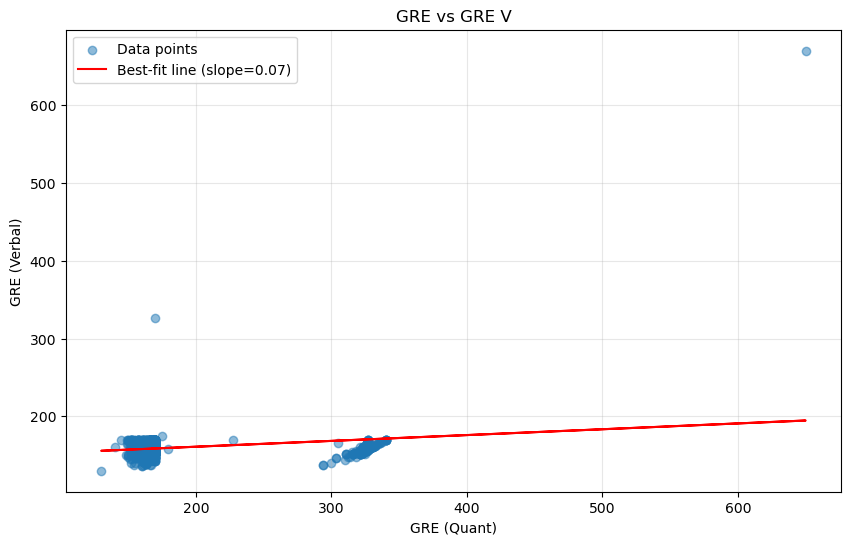

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# GRE vs GRE V Scatter Plot
plt.figure(figsize=(10, 6))

# Filter out rows where both GRE and GRE V are non-zero
valid_gre = df[(df['gre_quant'].notna()) & (df['gre_quant'] > 0) & 
               (df['gre_verbal'].notna()) & (df['gre_verbal'] > 0)]

plt.scatter(valid_gre['gre_quant'], valid_gre['gre_verbal'], alpha=0.5, label='Data points')

# Best-fit line
z = np.polyfit(valid_gre['gre_quant'], valid_gre['gre_verbal'], 1)
p = np.poly1d(z)
plt.plot(valid_gre['gre_quant'], p(valid_gre['gre_quant']), "r-", label=f'Best-fit line (slope={z[0]:.2f})')

plt.title('GRE vs GRE V')
plt.xlabel('GRE (Quant)')
plt.ylabel('GRE (Verbal)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('GRE-vs-GRE-V.png', dpi=300, bbox_inches='tight')
print("✅ Saved as 'GRE-vs-GRE-V.png'")
plt.show()

✅ Saved as 'GPA-vs-GRE.png'


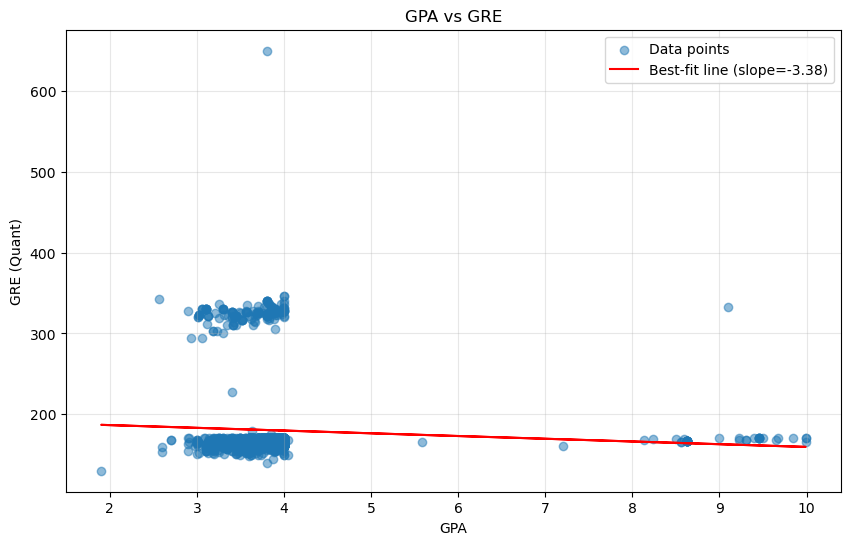

In [36]:
# GPA vs GRE Scatter Plot
plt.figure(figsize=(10, 6))

# Filter out rows where both GPA and GRE are non-zero
valid_gpa_gre = df[(df['gpa'].notna()) & (df['gpa'] > 0) & 
                   (df['gre_quant'].notna()) & (df['gre_quant'] > 0)]

plt.scatter(valid_gpa_gre['gpa'], valid_gpa_gre['gre_quant'], alpha=0.5, label='Data points')

# Best-fit line
z = np.polyfit(valid_gpa_gre['gpa'], valid_gpa_gre['gre_quant'], 1)
p = np.poly1d(z)
plt.plot(valid_gpa_gre['gpa'], p(valid_gpa_gre['gpa']), "r-", label=f'Best-fit line (slope={z[0]:.2f})')

plt.title('GPA vs GRE')
plt.xlabel('GPA')
plt.ylabel('GRE (Quant)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('GPA-vs-GRE.png', dpi=300, bbox_inches='tight')
print("✅ Saved as 'GPA-vs-GRE.png'")
plt.show()

✅ Saved as 'Degree-vs-International.png'


<Figure size 1000x600 with 0 Axes>

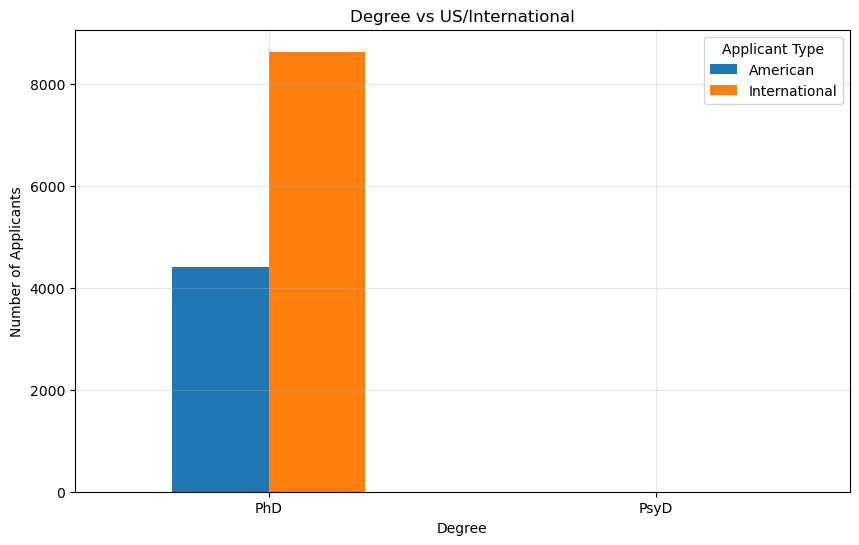

In [37]:
# Degree vs International Bar Chart
plt.figure(figsize=(10, 6))

# Create contingency table
degree_international = pd.crosstab(df['degree'], df['applicant_type'])
degree_international.plot(kind='bar', figsize=(10, 6))

plt.title('Degree vs US/International')
plt.xlabel('Degree')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)
plt.legend(title='Applicant Type')
plt.grid(True, alpha=0.3)

plt.savefig('Degree-vs-International.png', dpi=300, bbox_inches='tight')
print("✅ Saved as 'Degree-vs-International.png'")
plt.show()

Number of accepted applicants with valid decision dates: 0
⚠️ No accepted applicants with valid decision dates found. Creating placeholder chart.
✅ Saved placeholder as 'Acceptances-over-Time.png'


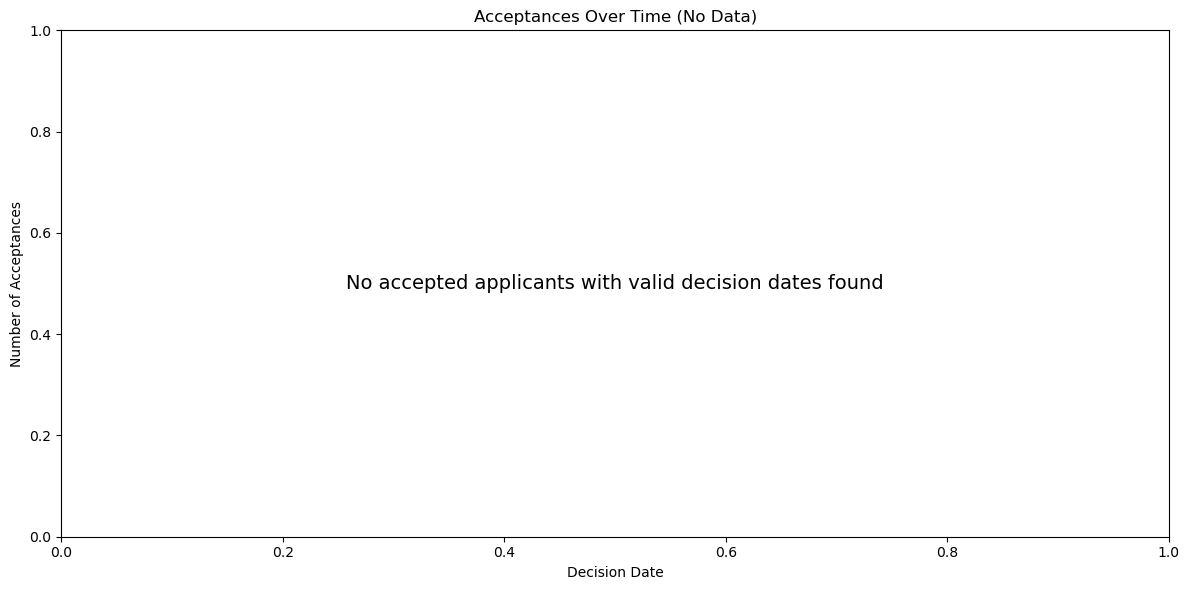

In [41]:
# First, check if there are any accepted applicants with valid decision dates
accepted_df = df[(df['outcome'] == 'Accepted') & (df['full_decision_date'].notna())]
print(f"Number of accepted applicants with valid decision dates: {len(accepted_df)}")

if len(accepted_df) > 0:
    # Create histogram with proper date formatting
    plt.figure(figsize=(12, 6))
    
    # Convert to datetime and sort
    accepted_dates = accepted_df['full_decision_date'].dropna()
    
    # Create bins from min to max date with 3-day intervals
    min_date = accepted_dates.min()
    max_date = accepted_dates.max()
    bins = pd.date_range(start=min_date, end=max_date + pd.Timedelta(days=3), freq='3D')
    
    plt.hist(accepted_dates, bins=bins, edgecolor='black', alpha=0.7, color='green')
    
    # Format x-axis dates
    import matplotlib.dates as mdates
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.xticks(rotation=45)
    
    plt.title('Acceptances Over Time (3-Day Bins)')
    plt.xlabel('Decision Date')
    plt.ylabel('Number of Acceptances')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('Acceptances-over-Time.png', dpi=300, bbox_inches='tight')
    print("✅ Saved as 'Acceptances-over-Time.png'")
    plt.show()
else:
    print("⚠️ No accepted applicants with valid decision dates found. Creating placeholder chart.")
    
    # Create placeholder chart
    plt.figure(figsize=(12, 6))
    plt.text(0.5, 0.5, 'No accepted applicants with valid decision dates found', 
             ha='center', va='center', fontsize=14, transform=plt.gca().transAxes)
    plt.title('Acceptances Over Time (No Data)')
    plt.xlabel('Decision Date')
    plt.ylabel('Number of Acceptances')
    plt.tight_layout()
    plt.savefig('Acceptances-over-Time.png', dpi=300, bbox_inches='tight')
    print("✅ Saved placeholder as 'Acceptances-over-Time.png'")
    plt.show()

✅ Saved as 'GPA-by-Outcome.png'


<Figure size 1000x600 with 0 Axes>

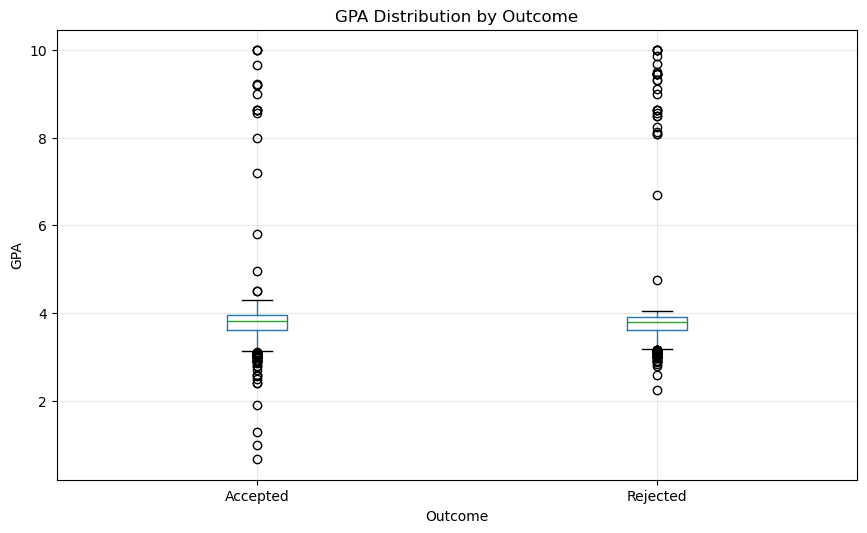

In [39]:
# GPA by Outcome boxplot
plt.figure(figsize=(10, 6))

# Filter for valid GPA values
valid_gpa_df = df[df['gpa'].notna()]

valid_gpa_df.boxplot(column='gpa', by='outcome', figsize=(10, 6))
plt.title('GPA Distribution by Outcome')
plt.suptitle('')  # Remove automatic title
plt.xlabel('Outcome')
plt.ylabel('GPA')
plt.grid(True, alpha=0.3)

plt.savefig('GPA-by-Outcome.png', dpi=300, bbox_inches='tight')
print("✅ Saved as 'GPA-by-Outcome.png'")
plt.show()

✅ Saved as 'Numeric-Correlation-Heatmap.png'


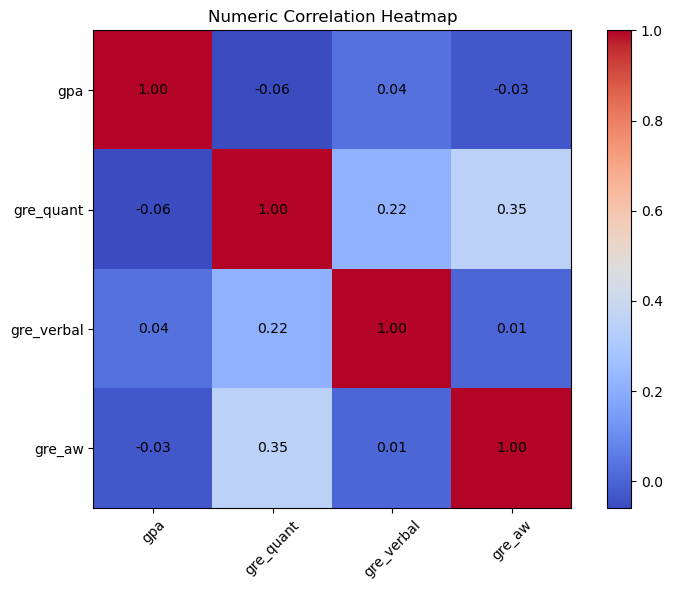

In [40]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))

numeric_cols = ['gpa', 'gre_quant', 'gre_verbal', 'gre_aw']
corr_df = df[numeric_cols].corr()

plt.imshow(corr_df, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=45)
plt.yticks(range(len(corr_df.columns)), corr_df.columns)
plt.title('Numeric Correlation Heatmap')

# Add correlation values on heatmap
for i in range(len(corr_df.columns)):
    for j in range(len(corr_df.columns)):
        plt.text(j, i, f'{corr_df.iloc[i, j]:.2f}', ha='center', va='center', color='black')

plt.tight_layout()
plt.savefig('Numeric-Correlation-Heatmap.png', dpi=300, bbox_inches='tight')
print("✅ Saved as 'Numeric-Correlation-Heatmap.png'")
plt.show()

In [42]:
# Q1: Average GRE of accepted PhD applicants
accepted_phd = df[(df['outcome'] == 'Accepted') & (df['degree'] == 'PhD') & (df['gre_quant'].notna())]
avg_gre_phd = accepted_phd['gre_quant'].mean()
print(f"Q1: Average GRE of accepted PhD applicants: {avg_gre_phd:.2f}")

Q1: Average GRE of accepted PhD applicants: 177.95


In [46]:
# Q3: Correlation analysis between GPA and GRE (using only rows with both values)
from scipy.stats import pearsonr

# Create a dataframe with only rows where both GPA and GRE are non-null
corr_data = df[['gpa', 'gre_quant']].dropna()
print(f"Number of rows with both GPA and GRE: {len(corr_data)}")

corr_gpa_gre = pearsonr(corr_data['gpa'], corr_data['gre_quant'])
print(f"Q3: GPA vs GRE correlation: {corr_gpa_gre[0]:.4f}, p-value: {corr_gpa_gre[1]:.4f}")

Number of rows with both GPA and GRE: 1841
Q3: GPA vs GRE correlation: -0.0595, p-value: 0.0106


In [47]:
# Q4: Correlation between GRE and GRE V
corr_data_gre = df[['gre_quant', 'gre_verbal']].dropna()
print(f"Number of rows with both GRE and GRE V: {len(corr_data_gre)}")

corr_gre_grev = pearsonr(corr_data_gre['gre_quant'], corr_data_gre['gre_verbal'])
print(f"Q4: GRE vs GRE V correlation: {corr_gre_grev[0]:.4f}, p-value: {corr_gre_grev[1]:.4f}")

Number of rows with both GRE and GRE V: 1957
Q4: GRE vs GRE V correlation: 0.2175, p-value: 0.0000


In [48]:
# Q5: Group comparison - Accepted vs Rejected GPA
from scipy.stats import ttest_ind

accepted_gpa = df[(df['outcome'] == 'Accepted') & (df['gpa'].notna())]['gpa']
rejected_gpa = df[(df['outcome'] == 'Rejected') & (df['gpa'].notna())]['gpa']

print(f"Accepted GPA count: {len(accepted_gpa)}, mean: {accepted_gpa.mean():.2f}")
print(f"Rejected GPA count: {len(rejected_gpa)}, mean: {rejected_gpa.mean():.2f}")

t_stat, p_val = ttest_ind(accepted_gpa, rejected_gpa)
print(f"Q5: T-test: t={t_stat:.4f}, p={p_val:.4f}")

Accepted GPA count: 1977, mean: 3.79
Rejected GPA count: 2288, mean: 3.81
Q5: T-test: t=-1.0564, p=0.2908


In [50]:
# Q1: Average GRE of accepted PhD applicants
accepted_phd = df[(df['outcome'] == 'Accepted') & (df['degree'] == 'PhD') & (df['gre_quant'].notna())]
avg_gre_phd = accepted_phd['gre_quant'].mean()
print(f"Q1: Average GRE of accepted PhD applicants: {avg_gre_phd:.2f}")

# Q2: Average GPA of accepted Master's applicants
accepted_masters = df[(df['outcome'] == 'Accepted') & (df['degree'] == "Master's") & (df['gpa'].notna())]
avg_gpa_masters = accepted_masters['gpa'].mean()
print(f"Q2: Average GPA of accepted Master's applicants: {avg_gpa_masters:.2f}")

Q1: Average GRE of accepted PhD applicants: 177.95
Q2: Average GPA of accepted Master's applicants: nan


In [51]:
# Q7: Remaining data quality issues
print("📊 Remaining Data Quality Issues:")
print(f"- Missing GPA: {df['gpa'].isna().sum()} rows ({df['gpa'].isna().sum() / len(df) * 100:.1f}%)")
print(f"- Missing GRE Quant: {df['gre_quant'].isna().sum()} rows ({df['gre_quant'].isna().sum() / len(df) * 100:.1f}%)")
print(f"- Missing GRE Verbal: {df['gre_verbal'].isna().sum()} rows ({df['gre_verbal'].isna().sum() / len(df) * 100:.1f}%)")
print(f"- Missing GRE AW: {df['gre_aw'].isna().sum()} rows ({df['gre_aw'].isna().sum() / len(df) * 100:.1f}%)")
print(f"- Missing outcome: {df['outcome'].isna().sum()} rows ({df['outcome'].isna().sum() / len(df) * 100:.1f}%)")

📊 Remaining Data Quality Issues:
- Missing GPA: 7907 rows (60.6%)
- Missing GRE Quant: 10980 rows (84.1%)
- Missing GRE Verbal: 11084 rows (84.9%)
- Missing GRE AW: 11179 rows (85.7%)
- Missing outcome: 3903 rows (29.9%)


In [58]:
# Complete re-cleaning with standardized degree values

# 1. Start with raw data
df2 = raw_df.copy()
print(f"Starting shape: {df2.shape}")

# 2. Remove rows where program is None
df2 = df2[df2['program'].notna()]

# 3. Standardize degree values
df2['degree'] = df2['degree'].replace('Masters', "Master's")

# 4. Keep only valid degree values
valid_degrees = ["Master's", "PhD", "PsyD"]
df2 = df2[df2['degree'].isin(valid_degrees)]
print(f"After degree filtering: {df2.shape}")

# 5. Keep only valid applicant types
valid_applicant_types = ['International', 'American', 'Other']
df2 = df2[df2['applicant_type'].isin(valid_applicant_types)]
print(f"After applicant type filtering: {df2.shape}")

# 6. Split acceptance_status into outcome and decision_date
def split_status(status):
    if pd.isna(status):
        return None, None
    status_str = str(status)
    if ' on ' in status_str:
        parts = status_str.split(' on ')
        return parts[0].strip(), parts[1].strip()
    return status_str, None

df2[['outcome', 'decision_date']] = df2['acceptance_status'].apply(lambda x: pd.Series(split_status(x)))

valid_outcomes = ['Waitlisted', 'Interviewed', 'Rejected', 'Accepted']
df2['outcome'] = df2['outcome'].where(df2['outcome'].isin(valid_outcomes), None)

# 7. Convert numeric columns
numeric_columns = ['gpa', 'gre_quant', 'gre_verbal', 'gre_aw']
for col in numeric_columns:
    if col in df2.columns:
        df2[col] = pd.to_numeric(df2[col], errors='coerce')

# 8. Convert added_on to datetime
df2['added_on'] = pd.to_datetime(df2['added_on'], errors='coerce')

print(f"✅ Final fixed dataset shape: {df2.shape}")
print(f"Unique degrees: {df2['degree'].unique()}")

Starting shape: (30000, 16)
After degree filtering: (29850, 16)
After applicant type filtering: (27258, 16)
✅ Final fixed dataset shape: (27258, 17)
Unique degrees: ['PhD' "Master's" 'PsyD']


In [59]:
# Q2: Average GPA of accepted Master's applicants
accepted_masters = df2[(df2['outcome'] == 'Accepted') & (df2['degree'] == "Master's") & (df2['gpa'].notna())]
avg_gpa_masters = accepted_masters['gpa'].mean()
print(f"Q2: Average GPA of accepted Master's applicants: {avg_gpa_masters:.2f}")
print(f"Number of accepted Master's applicants with GPA: {len(accepted_masters)}")

Q2: Average GPA of accepted Master's applicants: 4.09
Number of accepted Master's applicants with GPA: 3830


In [60]:
# Q6: Chi-square test - Degree vs Outcome
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df2['degree'], df2['outcome'])
print("Q6: Contingency table - Degree vs Outcome")
print(contingency_table)

chi2, p_val, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square: {chi2:.4f}, p-value: {p_val:.4f}")

Q6: Contingency table - Degree vs Outcome
outcome   Accepted  Rejected
degree                      
Master's      6200      4866
PhD           4139      5007
PsyD             1         0
Chi-square: 233.5255, p-value: 0.0000


In [61]:
print("📊 Remaining Data Quality Issues in Fixed Dataset:")
print(f"- Missing GPA: {df2['gpa'].isna().sum()} rows ({df2['gpa'].isna().sum() / len(df2) * 100:.1f}%)")
print(f"- Missing GRE Quant: {df2['gre_quant'].isna().sum()} rows ({df2['gre_quant'].isna().sum() / len(df2) * 100:.1f}%)")
print(f"- Missing GRE Verbal: {df2['gre_verbal'].isna().sum()} rows ({df2['gre_verbal'].isna().sum() / len(df2) * 100:.1f}%)")
print(f"- Missing GRE AW: {df2['gre_aw'].isna().sum()} rows ({df2['gre_aw'].isna().sum() / len(df2) * 100:.1f}%)")
print(f"- Missing outcome: {df2['outcome'].isna().sum()} rows ({df2['outcome'].isna().sum() / len(df2) * 100:.1f}%)")

📊 Remaining Data Quality Issues in Fixed Dataset:
- Missing GPA: 15180 rows (55.7%)
- Missing GRE Quant: 20077 rows (73.7%)
- Missing GRE Verbal: 20406 rows (74.9%)
- Missing GRE AW: 20676 rows (75.9%)
- Missing outcome: 7045 rows (25.8%)


In [68]:
import os

required_files = [
    'module_8.ipynb',
    'analytics.pdf',
    'cleaned_gradcafe.json',
    'missingness_summary.csv',
    'summary_statistics.csv',
    'initial_dataframe.png',
    'missingness_summary.png',
    'low_program_count.png',
    'date_based.png',
    'float_columns.png',
    'outlier_summary.png',
    'GRE-vs-GRE-V.png',
    'GPA-vs-GRE.png',
    'Degree-vs-International.png',
    'Acceptances-over-Time.png',
    'GPA-by-Outcome.png',
    'Numeric-Correlation-Heatmap.png'
]

print("📁 Module 8 File Check:")
print("-" * 40)
for f in required_files:
    if os.path.exists(f):
        print(f"✅ {f}")
    else:
        print(f"❌ {f} - MISSING")

📁 Module 8 File Check:
----------------------------------------
✅ module_8.ipynb
✅ analytics.pdf
✅ cleaned_gradcafe.json
✅ missingness_summary.csv
✅ summary_statistics.csv
✅ initial_dataframe.png
✅ missingness_summary.png
✅ low_program_count.png
✅ date_based.png
✅ float_columns.png
✅ outlier_summary.png
✅ GRE-vs-GRE-V.png
✅ GPA-vs-GRE.png
✅ Degree-vs-International.png
✅ Acceptances-over-Time.png
✅ GPA-by-Outcome.png
✅ Numeric-Correlation-Heatmap.png


In [66]:
# Count occurrences of each unique Program value
program_counts = df['program'].value_counts()
low_program_count = program_counts[program_counts < 3]
print("Programs occurring fewer than 3 times:")
print(low_program_count)

Programs occurring fewer than 3 times:
program
Engineering And Applied Science (Computer Science And Information Systems)    2
Computer Scienc                                                               2
Computer Science PhD                                                          2
Computer Science CDT In NLP ILCC                                              2
Computer Science (CICS)                                                       2
                                                                             ..
Electrical Engineering And Computer Sciences (EECS)                           1
Computer Engineering                                                          1
Computerr Science                                                             1
Computer Science & Informatics                                                1
EECS - Computer Science                                                       1
Name: count, Length: 126, dtype: int64


In [67]:
# Show date-based columns
df[['added_on', 'outcome', 'decision_date', 'term_year']].head(10)

,added_on,outcome,decision_date,term_year
0,2026-05-29,None,None,2026
3,2026-05-11,Rejected,None,2026
4,2026-05-06,Rejected,None,2026
5,2026-05-05,None,None,2026
6,2026-05-04,Rejected,None,2026
7,2026-05-04,Rejected,None,2026
9,NaT,Accepted,None,2026
10,NaT,Accepted,None,2026
11,NaT,Rejected,None,2026
12,NaT,Rejected,None,2026
